In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset_train = pd.read_csv("/content/NSE-TATAGLOBAL.csv")
training_set = dataset_train.iloc[:, 1:2].values

In [ ]:
dataset_train.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-09-28,234.05,235.95,230.20,233.50,233.75,3069914,7162.35
1,2018-09-27,234.55,236.80,231.10,233.80,233.25,5082859,11859.95
2,2018-09-26,240.00,240.00,232.50,235.00,234.25,2240909,5248.60
3,2018-09-25,233.30,236.75,232.00,236.25,236.10,2349368,5503.90
4,2018-09-24,233.55,239.20,230.75,234.00,233.30,3423509,7999.55


In [ ]:
dataset_train.shape

(2035, 8)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
training_set_scaled.shape

(2035, 1)

In [ ]:
x_train = []
y_train = []
for i in range(60, 1258):
    x_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
dataset_train.shape


(2035, 8)

In [ ]:
x_train.shape

(1198, 60)

In [ ]:
x_train.shape[0]

1198

In [ ]:
x_train.shape[1]

60

In [ ]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [ ]:
x_train.shape

(1198, 60, 1)

In [ ]:

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

In [ ]:
input_shape = (x_train.shape[1], 1)

In [ ]:
input_shape

(60, 1)

In [ ]:
regressor = Sequential()

In [ ]:
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (x_train.shape[1], 1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
regressor.add(Dropout(0.2))

In [ ]:
#Adding a second LSTM layer
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

In [ ]:
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

In [ ]:
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

In [ ]:
#Adding the output layer
regressor.add(Dense(units = 1))

#compiling the RNN
regressor.compile(optimizer=  'adam', loss = 'mean_squared_error')

#Fitting the RNN to the training set
regressor.fit(x_train, y_train, epochs = 20, batch_size = 32)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 214ms/step - loss: 0.0349
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - loss: 0.0039
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - loss: 0.0036
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - loss: 0.0029
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - loss: 0.0032
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - loss: 0.0029
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - loss: 0.0033
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - loss: 0.0031
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - loss: 0.0028
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - loss: 0.0027
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - loss: 0.0026
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - loss: 0.0024
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - loss: 0.0021
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - loss: 0.0027
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/st

In [ ]:
# part -3 making the predictions and visualizing the results

In [ ]:
dataset_test = pd.read_csv('/content/tatatest.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values

In [ ]:
dataset_test.shape

(16, 8)

In [ ]:
real_stock_price

array([[220.1 ],
       [221.1 ],
       [229.45],
       [230.3 ],
       [237.7 ],
       [237.1 ],
       [229.7 ],
       [226.25],
       [215.  ],
       [215.  ],
       [215.5 ],
       [208.  ],
       [217.  ],
       [223.5 ],
       [230.  ],
       [234.55]])

In [ ]:
#  Getting the predicted stock price of 2017

In [ ]:
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)

In [ ]:
dataset_total

,Open
0,234.05
1,234.55
2,240.00
3,233.30
4,233.55
...,...
11,208.00
12,217.00
13,223.50
14,230.00


In [ ]:
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values

In [ ]:
len(inputs)

76

In [ ]:
inputs = inputs.reshape(-1,1)

In [ ]:
inputs = sc.transform(inputs)
x_test = []
for i in range(60,76):
    x_test.append(inputs[i-60:i, 0])

In [ ]:
len(x_test)

16

In [ ]:
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 828ms/step


In [ ]:
real_stock_price

array([[220.1 ],
       [221.1 ],
       [229.45],
       [230.3 ],
       [237.7 ],
       [237.1 ],
       [229.7 ],
       [226.25],
       [215.  ],
       [215.  ],
       [215.5 ],
       [208.  ],
       [217.  ],
       [223.5 ],
       [230.  ],
       [234.55]])

In [ ]:
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)

In [ ]:
dataset_total

,Open
0,234.05
1,234.55
2,240.00
3,233.30
4,233.55
...,...
11,208.00
12,217.00
13,223.50
14,230.00


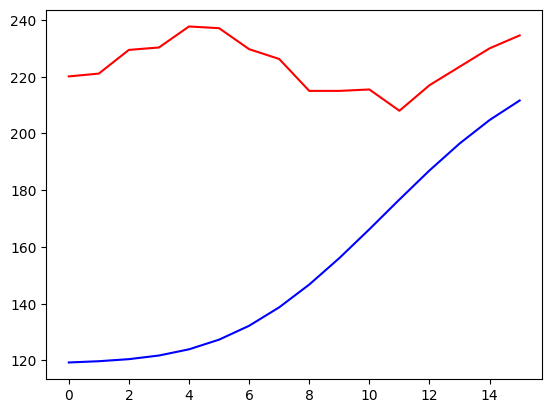

In [ ]:
plt.plot(real_stock_price, color = 'red', label = 'Real Google Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted Google Stock Price')